In [1]:
import os
from dotenv import load_dotenv

import geopandas
import pandas as pd
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
import math
import matplotlib.colors as mcolors

import cartopy.crs as ccrs

## Load Data

In [2]:
load_dotenv(dotenv_path="/home/emily_zuetell/projects/poreallas/env_local.env")
EFFECTS_URI = os.getenv("POREALLAS_EFFECTS_URI")
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

In [3]:
projected = xr.open_datatree(EFFECTS_URI, engine = 'zarr')
socioeconomics =  xr.open_zarr(SOCIOECONOMICS_URI)

In [4]:
_polygons = (
    geopandas.read_parquet("/home/emily_zuetell/projects/poreallas/scripts/data/impact_region.parquet")
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)
_polygons_effect = _polygons.merge(
    projected["/forecast"]["effect"]
    .mean(dim="number").groupby("time.month")
        .mean()
    .to_dataframe()
    .reset_index(),
    on="region",
)
_polygons_socioecon = _polygons.merge(
    socioeconomics.sel(year = 2026)[['pop0to4', 'pop5to64', 'pop65plus', 'pop']]
    .to_dataframe()
    .reset_index(),
    on="region",
)
_max_year = projected["/baseline"]["time"].max().dt.year.item()
# Subtracting 9 even though we want 10 year baseline because the time slice is an inclusive range.
_min_year = _max_year - 30
# inclusive - 29
baseline_period = slice(str(_min_year), str(_max_year))

In [5]:
da = projected['/forecast_hotonly']['effect']
da_baseline = projected['/baseline_hotonly']['effect']

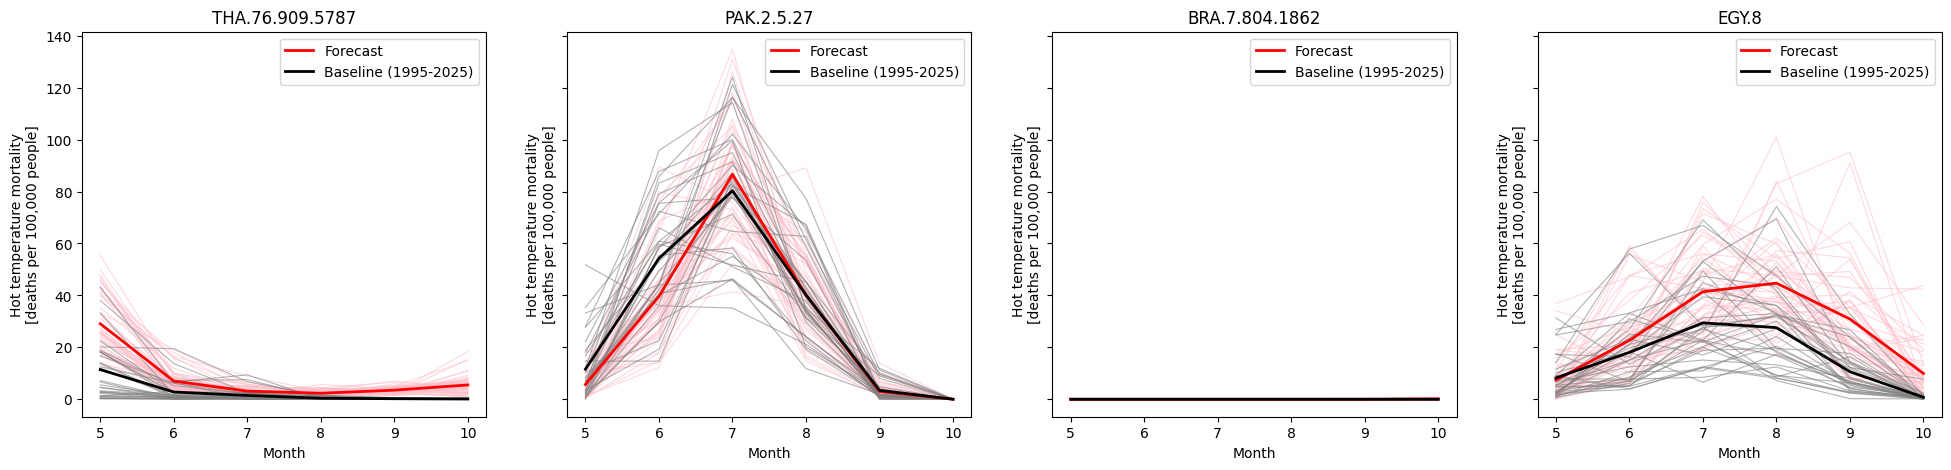

In [7]:
region_filters = ['THA.76.909.5787', 'PAK.2.5.27', "BRA.7.804.1862", "EGY.8"]  

fig, axes = plt.subplots(1, len(region_filters), figsize=(6*len(region_filters), 5), sharey=True)

for ax, region_filter in zip(axes, region_filters):
    ds = da.sel(region=region_filter, age_cohort='age65plus')
    ds_baseline = da_baseline.sel(region=region_filter, age_cohort='age65plus')

    ds = ds.assign_coords(month=ds['time'].dt.month)
    months_present = np.unique(ds['month'].values)

    for n in ds['number'].values:
        ds.sel(number=n).plot.line(x='month', add_legend=False, alpha=0.6, linewidth=0.8, color='pink', ax=ax)

    for year, da_year in ds_baseline.groupby('time.year'):
        da_year = da_year.assign_coords(month=da_year['time'].dt.month)
        da_year = da_year.sel(time=da_year['month'].isin(months_present))
        da_year.plot.line(x='month', add_legend=False, alpha=0.6, linewidth=0.8, color='gray', ax=ax)

    ds.mean(dim='number').plot.line(x='month', color='red', linewidth=2, ax=ax, label='Forecast')
    ds_baseline_month = ds_baseline.assign_coords(month=ds_baseline['time'].dt.month)
    ds_baseline_month = ds_baseline_month.sel(time=ds_baseline_month['month'].isin(months_present))
    ds_baseline_month.groupby('month').mean().plot.line(x='month', color='black', linewidth=2, ax=ax, label='Baseline (1995-2025)')

    ax.set_xticks(months_present)
    ax.set_xlabel('Month')
    ax.set_title(region_filter)
    ax.legend()

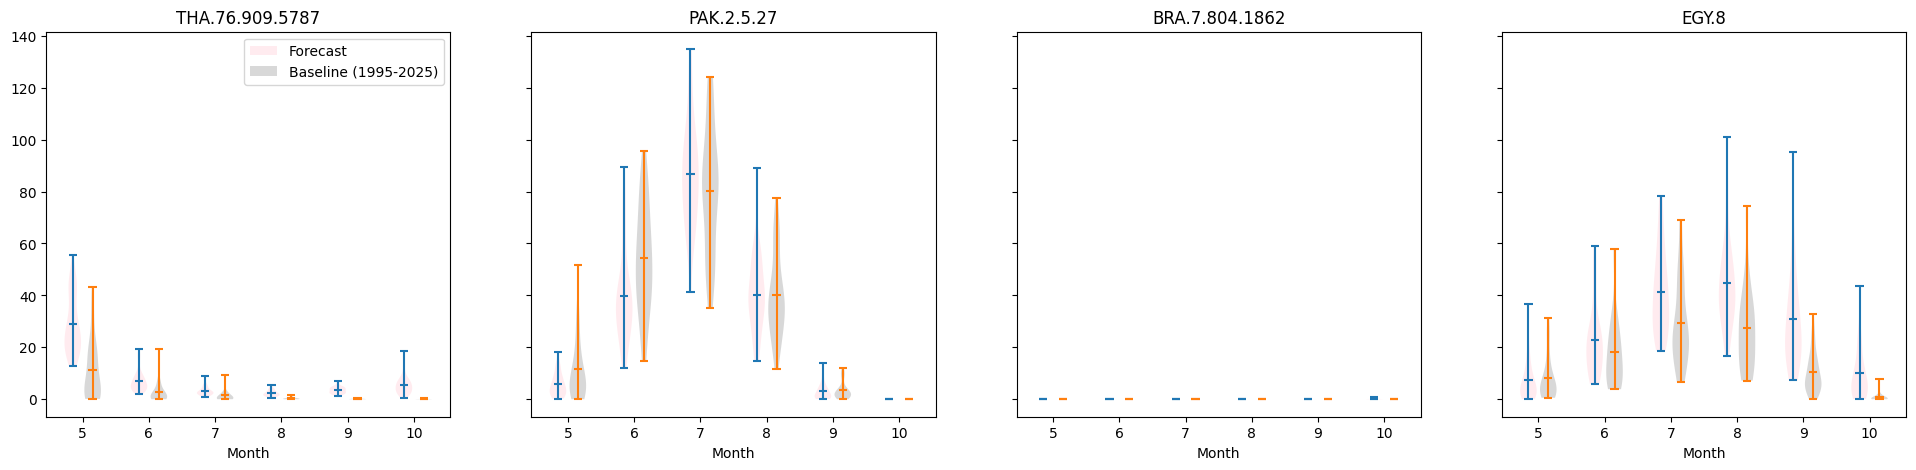

In [12]:
region_filters = ['THA.76.909.5787', 'PAK.2.5.27', "BRA.7.804.1862", "EGY.8"]  
#region_filters = ['THA.76.909.5787', 'PAK.2.5.27']  

fig, axes = plt.subplots(1, len(region_filters), figsize=(6*len(region_filters), 5), sharey=True)

offset = 0.15

for ax, region_filter in zip(axes, region_filters):
    ds = da.sel(region=region_filter, age_cohort='age65plus')
    ds_baseline = da_baseline.sel(region=region_filter, age_cohort='age65plus')

    ds = ds.assign_coords(month=ds['time'].dt.month)
    months_present = np.unique(ds['month'].values)

    ds_baseline = ds_baseline.assign_coords(month=ds_baseline['time'].dt.month)
    ds_baseline = ds_baseline.sel(time=ds_baseline['month'].isin(months_present))

    data_new = [ds.sel(time=ds['month'] == m).values.flatten() for m in months_present]
    data_baseline = [ds_baseline.sel(time=ds_baseline['month'] == m).values.flatten() for m in months_present]

    vp_new = ax.violinplot(data_new, positions=months_present - offset, showmeans=True, widths=0.25)
    vp_baseline = ax.violinplot(data_baseline, positions=months_present + offset, showmeans=True, widths=0.25)

    for body in vp_new['bodies']:
        body.set_facecolor('pink')
    for body in vp_baseline['bodies']:
        body.set_facecolor('gray')

    ax.set_xticks(months_present)
    ax.set_xlabel('Month')
    ax.set_title(region_filter)

axes[0].legend([vp_new['bodies'][0], vp_baseline['bodies'][0]], ['Forecast', 'Baseline (1995-2025)'])

In [35]:
da = projected['/forecast']['effect']
p10 = da.quantile(0.10, dim="number")
p90 = da.quantile(0.90, dim="number")
prange = p90 - p10

ds_out = xr.Dataset({
    "p10": p10.drop_vars("quantile"),
    "p90": p90.drop_vars("quantile"),
    "range": prange.drop_vars("quantile", errors="ignore")
})
_polygons_num = _polygons.merge(ds_out.groupby("time.month")
        .mean()
    .to_dataframe()
    .reset_index(),
    on="region",)

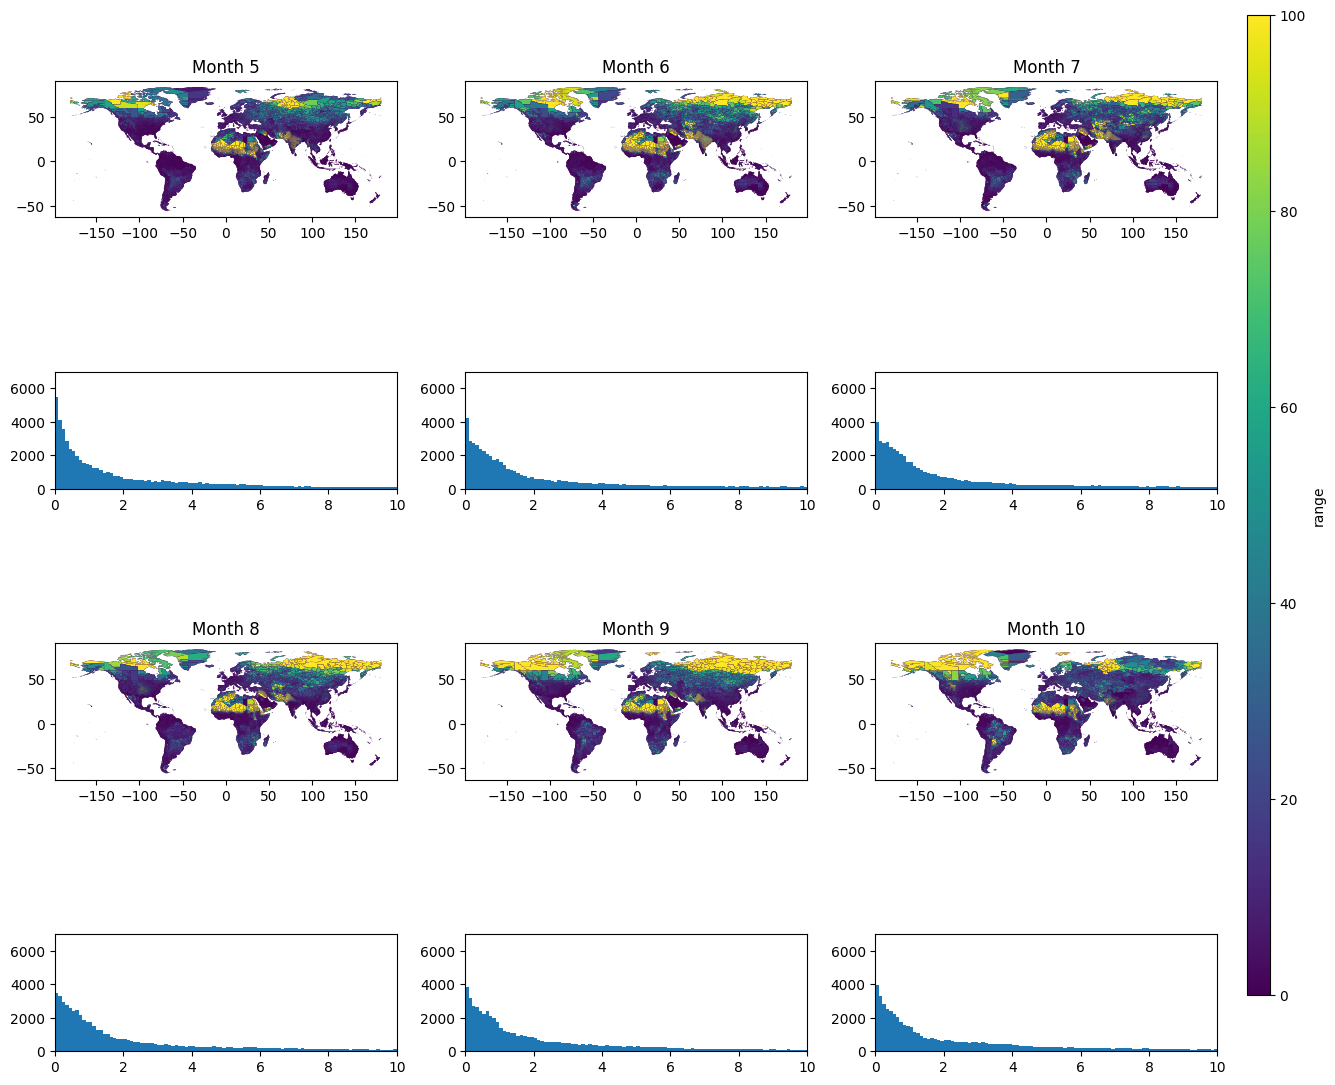

In [36]:
months = sorted(_polygons_num['month'].unique())
n = len(months)
ncols = math.ceil(n / 2)
fig, axes = plt.subplots(4, ncols, figsize=(5*ncols, 14),
                          gridspec_kw={'height_ratios': [3, 1, 3, 1]})

map_axes = list(axes[0]) + list(axes[2])
hist_axes = list(axes[1]) + list(axes[3])

norm = plt.Normalize(vmin=0, vmax=100)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)

xmin, xmax = 0, 10

for map_ax, hist_ax, m in zip(map_axes, hist_axes, months):
    subset = _polygons_num[_polygons_num['month']==m]
    subset.plot(column='range', ax=map_ax, norm=norm, cmap='viridis', legend=False)
    map_ax.set_title(f"Month {m}")

    hist_ax.hist(subset['range'], bins=100, range=(xmin, xmax))
    hist_ax.set_xlim(xmin, xmax)
    hist_ax.set_ylim(0, 7000)

for map_ax, hist_ax in zip(map_axes[n:], hist_axes[n:]):
    map_ax.set_visible(False)
    hist_ax.set_visible(False)

fig.canvas.draw()  # force geopandas' equal-aspect positions to finalize

for map_ax, hist_ax in zip(map_axes, hist_axes):
    if map_ax.get_visible():
        map_pos = map_ax.get_position()
        hist_pos = hist_ax.get_position()
        hist_ax.set_position([map_pos.x0, hist_pos.y0, map_pos.width, hist_pos.height])

cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # dedicated colorbar axis, adjust as needed
fig.colorbar(sm, cax=cax, label='range')

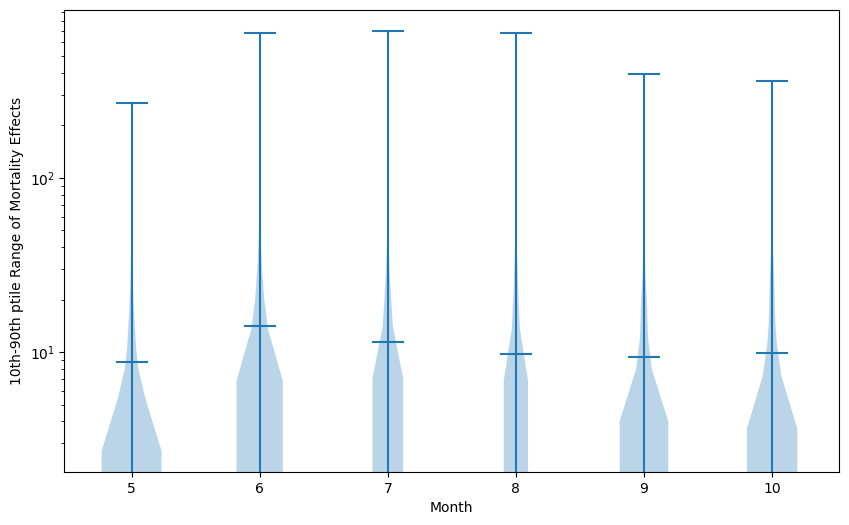

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

months = sorted(_polygons_num['month'].unique())
data = [_polygons_num.loc[_polygons_num['month'] == m, 'range'] for m in months]

ax.violinplot(data, positions=months, showmeans=True)
ax.set_xticks(months)
ax.set_xlabel('Month')
ax.set_ylabel('10th-90th ptile Range of Mortality Effects')
ax.set_yscale('log')

## Compute Impact

In [ ]:
#Hotonly
_baseline = (
    projected["/baseline_hotonly"]["effect"]
    .sel(time=baseline_period)
    .groupby("time.month")
    .mean()
)
_forecast = (
    projected["/forecast_hotonly"]["effect"].mean(dim="number").groupby("time.month").mean()
)
impact = _forecast - _baseline
impact.name = "impact"
impact.attrs["long_name"] = "Temperature mortality impact"
impact.attrs["units"] = "Deaths per 100,000 people"
impact.attrs['hotonly'] = True

_polygons_impact_hotonly = _polygons.merge(
    impact.to_dataframe().reset_index(),
    on="region",
)
## Net
_baseline = (
    projected["/baseline"]["effect"]
    .sel(time=baseline_period)
    .groupby("time.month")
    .mean()
)
_forecast = (
    projected["/forecast"]["effect"].mean(dim="number").groupby("time.month").mean()
)
impact = _forecast - _baseline
impact.name = "impact"
impact.attrs["long_name"] = "Temperature mortality impact"
impact.attrs["units"] = "Deaths per 100,000 people"
impact.attrs['hotonly'] = False

_polygons_impact_net = _polygons.merge(
    impact.to_dataframe().reset_index(),
    on="region",
)

## Climate Data

In [ ]:
ds_forecast = xr.open_zarr("./data/tas_forecast.zarr")
ds_forecast = ds_forecast.swap_dims({'forecast_period': 'valid_time'})

## Hindcast for Bias Adjustment ##
ds_hindcast = xr.open_dataset('./data/s51_hcm_allmonths.nc')
da_hindcast = ds_hindcast['t2m'].assign_coords(forecast_reference_time=ds_hindcast.forecast_reference_time.dt.month).rename({'forecast_reference_time':'month'})

ds_era5_hcperiod = xr.open_dataset("./data/era5_monthly_1981_2016.nc")
da_era5 = ds_era5_hcperiod['t2m'].sel(valid_time = slice("1993-01-01", "2016-12-01")).groupby("valid_time.month").mean()

#regridder = xe.Regridder(da_era5, da_hindcast, "bilinear")
#da_era5_regridded = regridder(da_era5)
da_era5_regridded = da_era5.interp_like(da_hindcast, method="linear")

## Historical Baselin ##
era5_mortality_baseline = xr.open_zarr('/home/emily_zuetell/projects/poreallas/scripts/data/tas_ERA5.zarr')
era5_mortality_baseline = era5_mortality_baseline['tas'].sel(time = slice("1995-01-01", "2025-12-31")).groupby("time.month").mean()

## Diagnostic Panels

In [ ]:
import cartopy.crs as ccrs
from scipy.interpolate import interp1d

rate = False
hotonly = False
age_weight = True
use_log = False
density_hist = True
regional_sum = pop_weight_sum(col='impact', rate=rate, hotonly = hotonly, age_weight=age_weight)

#region_filter = "PAK.2.5.27"
#region_filter = "IND.16.203.735"
#region_filter = "BRA.7.804.1862"
#region_filter = "IND.29.439.1743"
region_filter = "CHN.11.109.767"  # set to None for global
#region_filter = "COD.3.15.51" 
#region_filter = "THA.76.909.5787"
#region_filter = "HRV.R4acd3465906d6fba"
#region_filter = "EGY.8"
#region_filter = 'BRA.9.R7ae8d9b7a4e0454f'
#region_filter = 'ZMB.9.67'

months = sorted(regional_sum['month'].unique())[1:]
base_month = months[0]
lead_by_month = {month: (month - base_month + 1) for month in months}

ncols = 3
n_months = len(months)
n_pairs = math.ceil(n_months / ncols)
total_rows = n_pairs * 3

# --- Region bbox ---
if region_filter:
    _country = _polygons[_polygons.index == region_filter].to_crs("EPSG:4326")
    minx, miny, maxx, maxy = _country.total_bounds
    bbox_pad = 1
    _country_proj = _country.to_crs("ESRI:54030")
    bminx, bminy, bmaxx, bmaxy = _country_proj.total_bounds
    pad_proj = 50000

fig = plt.figure(figsize=(5 * ncols, 6 * n_pairs))

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

gs = GridSpec(n_pairs, 1, figure=fig, hspace=0.4)

top_axes = []
bot_axes = []
hist_axes = []

for pair_row in range(n_pairs):
    inner_gs = GridSpecFromSubplotSpec(3, ncols, subplot_spec=gs[pair_row],
                                       hspace=0.15, wspace=0.25,
                                       height_ratios=[2, 2, 1.2])
    for col in range(ncols):
        i = pair_row * ncols + col
        if i >= n_months:
            break
        ax_top = fig.add_subplot(inner_gs[0, col], projection=ccrs.PlateCarree())
        ax_bot = fig.add_subplot(inner_gs[1, col])
        ax_hist = fig.add_subplot(inner_gs[2, col])
        top_axes.append(ax_top)
        bot_axes.append(ax_bot)
        hist_axes.append(ax_hist)

# --- Precompute temperature bias adjustments ---
bias_adj_all = []
bias_adj_iso_all = []
for month in months:
    lead = lead_by_month[month]
    bias_adjustment = (
        da_hindcast.sel(month=(month - lead + 1), forecastMonth=lead)
        - da_era5_regridded.sel(month=month)
    )
    bias_adj_fc = (
        ds_forecast.sel(valid_time=ds_forecast.valid_time.dt.month == month)['tas']
        .mean(dim=['number', 'valid_time'])
        .squeeze()
        - era5_mortality_baseline.sel(month=month)
        - bias_adjustment
    )
    bias_adj_all.append(bias_adj_fc)

    if region_filter:
        def roll_lon(da):
            return da.assign_coords(
                longitude=((da.longitude + 180) % 360 - 180)
            ).sortby('longitude')

        bias_adj_fc_iso = (
            roll_lon(ds_forecast.sel(valid_time=ds_forecast.valid_time.dt.month == month)['tas'])
            .squeeze()
            - roll_lon(bias_adjustment)
        ).sel(
            latitude=slice(maxy + bbox_pad, miny - bbox_pad),
            longitude=slice(minx - bbox_pad, maxx + bbox_pad),
        )

        bias_adj_iso_all.append(bias_adj_fc_iso)

# --- Shared impact norm ---

_polygons_all = _polygons.merge(regional_sum.reset_index(), on="region").to_crs("ESRI:54030")
absmax_impact = _polygons_all['age_weighted_total'].abs().quantile(0.95)
if use_log:
    norm_impact = mcolors.SymLogNorm(linthresh=1, vmin=-absmax_impact, vmax=absmax_impact)
else:
    norm_impact = mcolors.TwoSlopeNorm(vmin=-absmax_impact, vcenter=0, vmax=absmax_impact)

era5_rolled = era5_daily.assign_coords(
    longitude=((era5_daily.longitude + 180) % 360 - 180)
).sortby('longitude')

era5_local = era5_rolled.sel(
    latitude=slice(maxy + bbox_pad, miny - bbox_pad),
    longitude=slice(minx - bbox_pad, maxx + bbox_pad),
)
era5_local = (
    era5_local['tas']
    .sel(time=slice("1995-01-01", "2025-12-31"))
    .isel(time=era5_local.time.dt.month.isin(months))
)
xmin = min(era5_local.values.flatten().min(), min(b.values.flatten().min() for b in bias_adj_iso_all))
xmax = max(era5_local.values.flatten().max(), max(b.values.flatten().max() for b in bias_adj_iso_all))

# --- Plot ---
for i, month in enumerate(months):
    ax_top = top_axes[i]
    ax_bot = bot_axes[i]
    ax_hist = hist_axes[i]
    month_label = pd.Timestamp(2026, month, 1).strftime('%B')

    # Top: temperature
    im_temp = bias_adj_all[i].plot(
        ax=ax_top,
        transform=ccrs.PlateCarree(),
        vmin=-5, vmax=5,
        cmap='RdBu_r',
        add_colorbar=False,
    )
    ax_top.set_title(month_label)
    ax_top.coastlines()
    if region_filter:
        ax_top.set_extent(
            [minx - bbox_pad, maxx + bbox_pad, miny - bbox_pad, maxy + bbox_pad],
            crs=ccrs.PlateCarree()
        )

    # Middle: impact
    _polygons_data = _polygons.merge(
        regional_sum[regional_sum['month'] == month].reset_index(),
        on="region",
    )
    _plot_data = _polygons_data.to_crs("ESRI:54030")
    _plot_data.plot(
        column="age_weighted_total",
        legend=False,
        ax=ax_bot,
        cmap="seismic",
        norm=norm_impact,
        edgecolor='black',
        linewidth=0.03,
    )
    ax_bot.set_axis_off()
    if region_filter:
        ax_bot.set_xlim(bminx - pad_proj, bmaxx + pad_proj)
        ax_bot.set_ylim(bminy - pad_proj, bmaxy + pad_proj)

    # Bottom: histogram
    if region_filter:
        era5_local_month = era5_local.sel(time=era5_local.time.dt.month == month)


        ref_vals = betas_mmt['mmt'].sel(region=region_filter).sel(age_cohort='age65plus') + 273.15
        betas = betas_mmt['beta_hotonly'] if hotonly else betas_mmt['beta']
        da_temp_bins = betas.sel(region=region_filter).sel(age_cohort='age65plus')
        da_temp_bins['tas_bin'] = da_temp_bins['tas_bin'] + 273.15

        # Build interpolator for response curve
        response_interp = interp1d(
            da_temp_bins.coords['tas_bin'].values,
            da_temp_bins.values,
            bounds_error=False, fill_value=0
        )



        ax_hist.hist(bias_adj_iso_all[i].values.flatten(), bins=50, alpha=0.5, label="Forecast", density=density_hist)
        ax_hist.hist(era5_local_month.values.flatten(), bins=50, alpha=0.5, label="ERA5 (1995–2025)", density=density_hist)
        ax_hist.axvline(ref_vals.values, color='black', linewidth=0.5, alpha=0.7, label="MMT")

        ax_hist2 = ax_hist.twinx()
        ax_hist2.plot(da_temp_bins.coords['tas_bin'], da_temp_bins.values, color='black', linewidth=1.5, label="Response curve")
        ax_hist2.set_ylabel("Response")
        ax_hist2.set_ylim(-10, 30)

        ## Response CDFs
        era5_centers, era5_cdf = weighted_cdf(era5_local_month.values.flatten())
        fc_centers, fc_cdf = weighted_cdf(bias_adj_iso_all[i].values.flatten())

        ax3 = ax_hist.twinx()
        ax3.spines["right"].set_position(("axes", 1.15))

        ax3.plot(fc_centers, fc_cdf, label="Forecast weighted CDF")
        ax3.plot(era5_centers, era5_cdf, label="ERA5 weighted CDF")


        ax_hist.legend(fontsize=7)
        ax_hist.set_xlabel("Tas (K)")
        ax_hist.set_ylabel("Density")
        ax_hist.set_xlim(xmin, xmax)
        ax_hist2.set_xlim(xmin, xmax)
    else:
        ax_hist.set_visible(False)

# --- Colorbars ---
ax_oct_top = top_axes[-1]
ax_oct_bot = bot_axes[-1]

fig.canvas.draw()

pos_top = ax_oct_top.get_position()
cax_temp = fig.add_axes([pos_top.x1 + 0.01, pos_top.y0+0.02, 0.01, pos_top.height])
sm_temp = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=-5, vmax=5))
fig.colorbar(sm_temp, cax=cax_temp, label="ΔTas (K)\nBaseline: 1995-2025")

pos_bot = ax_oct_bot.get_position()
cax_impact = fig.add_axes([pos_bot.x1 + 0.01, pos_bot.y0, 0.015, pos_bot.height])
sm_impact = plt.cm.ScalarMappable(cmap="seismic", norm=norm_impact)
label01 = "Monthly Impact"
units = "[deaths/100k]" if rate else "[num. deaths]"
label = f"{label01}:\n{projected['/forecast']['effect'].attrs['long_name']}\n{units}"
fig.colorbar(sm_impact, cax=cax_impact, label=label)


fig.subplots_adjust(top=0.93)

title_region = f" {region_filter}" if region_filter else ""
ag_label = "Age-Weighted" if age_weight else "Age Cohort: 65+"
label = 'Death Rate' if rate else "Deaths"
label_h = 'Hotonly' if hotonly else 'Net'

fig.suptitle(f"{ag_label} {label_h} {label}:{title_region}", fontsize=14)


label_f = 'death_rate' if rate else "deaths"

fig.savefig(f'{label_h}_{label_f}_agewtd{f'_{region_filter}' if region_filter else ''}.png', dpi=600, bbox_inches="tight")